## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

from Bio.SeqUtils.ProtParam import ProteinAnalysis

import xgboost as xgb
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## Cargar dataset

In [2]:
df = pd.read_csv("dataset.csv")

embeddings = np.load("protein_embeddings.npy")
pdl1_embedding = np.load("pdl1_embedding.npy")

print("Dataset shape:", df.shape)
print("Embeddings shape:", embeddings.shape)
print("PDL1 embedding shape:", pdl1_embedding.shape)

Dataset shape: (28800, 8)
Embeddings shape: (28800, 2560)
PDL1 embedding shape: (1280,)


## Separar binder embedding

In [3]:
binder_embeddings = embeddings[:, :1280]
print(binder_embeddings.shape)

(28800, 1280)


## Crear interaction features con PDL1

In [4]:
target_matrix = np.tile(pdl1_embedding, (binder_embeddings.shape[0], 1))

interaction_features = np.concatenate([
    binder_embeddings,
    np.abs(binder_embeddings - target_matrix),
    binder_embeddings * target_matrix
], axis=1)

print("Interaction features shape:", interaction_features.shape)

Interaction features shape: (28800, 3840)


## Features biofísicas del péptido

In [5]:
def clean_peptide(seq):
    return seq.split("/")[0]
    
def peptide_features(seq):
    seq = clean_peptide(seq)
    analysis = ProteinAnalysis(seq)

    return [
        len(seq),
        analysis.gravy(),
        analysis.aromaticity(),
        analysis.isoelectric_point()
    ]


bio_features = np.array([
    peptide_features(seq) for seq in df["seq"]
])

print("Bio features shape:", bio_features.shape)

Bio features shape: (28800, 4)


## Combinar features

In [6]:
X = np.concatenate([
    interaction_features,
    bio_features
], axis=1)

print("Total feature shape:", X.shape)

Total feature shape: (28800, 3844)


## Targets de clasificación

In [7]:
df["ptm_class"] = (df["ptm"] > 0.6).astype(int)
df["iptm_class"] = (df["i_ptm"] > 0.6).astype(int)

y = df[["ptm_class", "iptm_class"]].values

print("Targets shape:", y.shape)

Targets shape: (28800, 2)


## Train test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## StandardScaler

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## PCA solo al binder

In [10]:
binder_block = X_train_scaled[:, :1280]

pca = PCA(n_components=200)

binder_pca_train = pca.fit_transform(binder_block)
binder_pca_test = pca.transform(X_test_scaled[:, :1280])

In [11]:
X_train_pca = np.concatenate([
    binder_pca_train,
    X_train_scaled[:, 1280:]
], axis=1)

X_test_pca = np.concatenate([
    binder_pca_test,
    X_test_scaled[:, 1280:]
], axis=1)

print(X_train_pca.shape)

(23040, 2764)


## Modelo 1 — XGBoost

In [14]:
import sklearn
import xgboost

print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

from sklearn import set_config
set_config(display="text")

sklearn: 1.6.1
xgboost: 2.1.2


In [15]:
model_ptm = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8
)

model_iptm = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8
)

model_ptm.fit(X_train_pca, y_train[:,0])
model_iptm.fit(X_train_pca, y_train[:,1])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

## Evaluación XGBoost

In [16]:
pred_ptm = model_ptm.predict(X_test_pca)
pred_iptm = model_iptm.predict(X_test_pca)

print("PTM classification")
print(classification_report(y_test[:,0], pred_ptm))

print("iPTM classification")
print(classification_report(y_test[:,1], pred_iptm))

PTM classification
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.99      1.00      0.99      5686

    accuracy                           0.99      5760
   macro avg       0.49      0.50      0.50      5760
weighted avg       0.97      0.99      0.98      5760

iPTM classification
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      3558
           1       0.79      0.99      0.88      2202

    accuracy                           0.90      5760
   macro avg       0.89      0.91      0.89      5760
weighted avg       0.92      0.90      0.90      5760



C:\Users\Nitro\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Nitro\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Nitro\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

## ROC curve

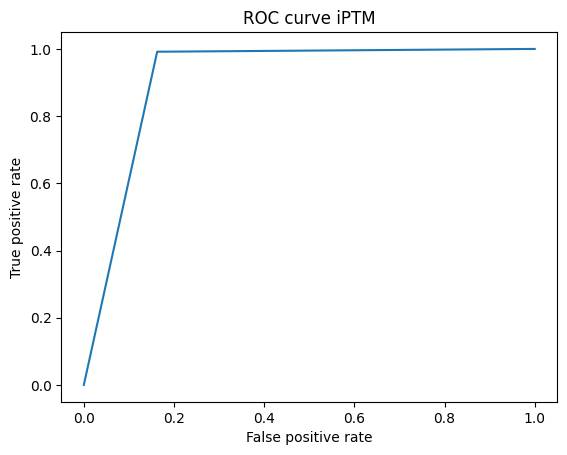

In [17]:
prob_iptm = model_iptm.predict_proba(X_test_pca)[:,1]

fpr, tpr, _ = roc_curve(y_test[:,1], prob_iptm)

plt.plot(fpr, tpr)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve iPTM")
plt.show()

## Modelo 2 — Deep Neural Network

In [18]:
class PeptideDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X).float()
        self.y = torch.tensor(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## DataLoader

In [19]:
train_dataset = PeptideDataset(X_train_pca, y_train)
test_dataset = PeptideDataset(X_test_pca, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128)

## Red neuronal multitask

In [20]:
class MLP(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 2),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

## Inicializar modelo

In [21]:
model = MLP(X_train_pca.shape[1])

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

criterion = nn.BCELoss()

## Training loop

In [22]:
epochs = 20

for epoch in range(epochs):

    total_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch", epoch, "loss:", total_loss)

Epoch 0 loss: 50.38603910803795
Epoch 1 loss: 47.88570033758879
Epoch 2 loss: 46.58320231735706
Epoch 3 loss: 45.3326950147748
Epoch 4 loss: 44.444983795285225
Epoch 5 loss: 43.88923344761133
Epoch 6 loss: 44.413711316883564
Epoch 7 loss: 44.062193274497986
Epoch 8 loss: 43.12348882108927
Epoch 9 loss: 43.09913828969002
Epoch 10 loss: 42.96571257710457
Epoch 11 loss: 43.103348568081856
Epoch 12 loss: 43.07975563406944
Epoch 13 loss: 42.934165209531784
Epoch 14 loss: 42.770228169858456
Epoch 15 loss: 43.01955904066563
Epoch 16 loss: 43.118235163390636
Epoch 17 loss: 43.19733498245478
Epoch 18 loss: 43.359851866960526
Epoch 19 loss: 43.55869008600712


## Evaluación red neuronal

In [23]:
model.eval()

preds = []
targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        preds.append(outputs.numpy())
        targets.append(y_batch.numpy())

preds = np.vstack(preds)
targets = np.vstack(targets)

pred_classes = (preds > 0.5).astype(int)

print(classification_report(targets[:,1], pred_classes[:,1]))

              precision    recall  f1-score   support

         0.0       0.99      0.84      0.91      3558
         1.0       0.79      0.99      0.88      2202

    accuracy                           0.90      5760
   macro avg       0.89      0.91      0.89      5760
weighted avg       0.92      0.90      0.90      5760



## Gráfica de predicciones

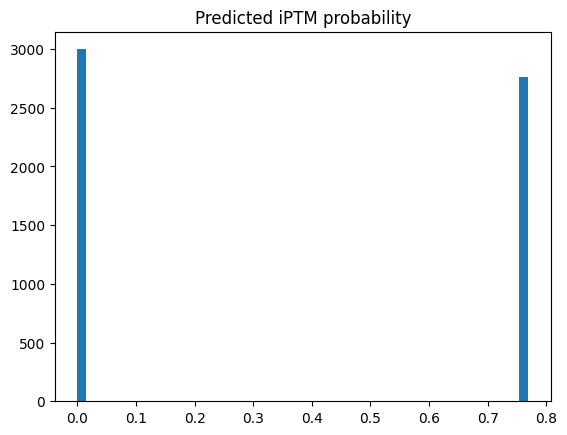

In [24]:
plt.hist(preds[:,1], bins=50)
plt.title("Predicted iPTM probability")
plt.show()